# Data

In [1]:
import numpy as np
import pandas  as pd
import os
from IPython.display import clear_output
import pygad
from classes import MACDBacktester, backtest

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\data')
#os.getcwd()
df = pd.read_csv('BTCUSD_1m_2024-09-23.csv', index_col='time', usecols=['time', 'open', 'high', 'low', 'close', 'tick_volume'])
df.index = pd.to_datetime(df.index)

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\genetic')

price_column = 'close'
date_split = "2024-10-1"
tf = '1h'

timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)

working_dataset = df[tf]

df_train = working_dataset[:date_split]
df_test = working_dataset[date_split:]

signal_price = 'close'
real_price = 'close'

clear_output()


# Algorithm


In [ ]:
import pygad
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# Suppress specific warnings (UserWarnings in this case)
warnings.filterwarnings("ignore", category=UserWarning)

class MACD_GA:
    def __init__(self, df_train, fast_range=(1, 50), slow_range=(2, 50), signal_range=(2, 30),\
                  generations=120, population=50, mating_parents=25, real_price='close', signal_price = 'close' ):
        self.df_train = df_train
        self.fast_range = fast_range
        self.slow_range = slow_range
        self.signal_range = signal_range
        self.generations = generations
        self.population = population
        self.mating_parents = mating_parents
        self.ga_instance = None
        self.best_solution = None
        self.real_price = real_price
        self.signal_price = signal_price

    # @staticmethod
    def macd(self, data, fast, slow, signal):
        data['ema_fast'] = data[self.signal_price].ewm(span=fast, min_periods=1, adjust=False).mean()
        data['ema_slow'] = data[self.signal_price].ewm(span=slow, min_periods=1, adjust=False).mean()
        data['macd_line'] = data['ema_fast'] - data['ema_slow']
        data['signal_line'] = data['macd_line'].ewm(span=signal, adjust=False).mean()
        return data

    @staticmethod
    def backtest(data):
        buy_signals = (data['macd_line'] > data['signal_line']) & (data['macd_line'].shift(1) <= data['signal_line'].shift(1))
        sell_signals = (data['macd_line'] < data['signal_line']) & (data['macd_line'].shift(1) >= data['signal_line'].shift(1))

        positions = pd.Series(index=data.index, data=np.nan)
        positions[buy_signals] = 1
        positions[sell_signals] = 0
        positions.ffill(inplace=True)
        positions.fillna(0, inplace=True)

        data['Strategy'] = positions.shift(1) * (data['close'].pct_change())
        return data['Strategy'].cumsum().iloc[-1]

    def fitness_function(self, ga_instance, solution, solution_idx):
        ema_fast, ema_slow, signal = int(solution[0]), int(solution[1]), int(solution[2])
        if ema_fast >= ema_slow - 1:
            return -np.inf
        if ema_fast < 1 or ema_slow < ema_fast + 1 or signal < 1:
            return -np.inf
        temp_data = self.macd(self.df_train.copy(), ema_fast, ema_slow, signal)
        profit = self.backtest(temp_data)
        return profit

    def run_ga(self):
        # Initialize the GA instance
        self.ga_instance = pygad.GA(
            num_generations=self.generations,
            sol_per_pop=self.population,
            num_parents_mating=self.mating_parents,
            fitness_func=self.fitness_function,
            crossover_type="two_points",
            crossover_probability=0.8,
            num_genes=3,
            init_range_low=[self.fast_range[0], self.slow_range[0], self.signal_range[0]],
            init_range_high=[self.fast_range[1], self.slow_range[1], self.signal_range[1]],
            mutation_percent_genes=50,
            gene_type=int,
            save_solutions=True
        )
        # Run the GA
        self.ga_instance.run()
        # Save the best solution
        self.best_solution = self.ga_instance.best_solution()

    def get_best_parameters(self):
        if self.best_solution is None:
            return None
        solution, fitness, _ = self.best_solution
        return {
            "Fast EMA": int(solution[0]),
            "Slow EMA": int(solution[1]),
            "Signal Line": int(solution[2]),
            "Net Profit": fitness
        }

    def plot_results(self):
        if self.ga_instance:
            self.ga_instance.plot_fitness(title="Fitness Evolution")
            # self.ga_instance.plot_fitness()
            self.ga_instance.plot_genes(title="Fast, Slow, Signal")
            self.ga_instance.plot_new_solution_rate(title="New Solution Rate Evolution")


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Best Parameters: {'Fast EMA': 2, 'Slow EMA': 29, 'Signal Line': 16, 'Net Profit': 0.15928444515343576}


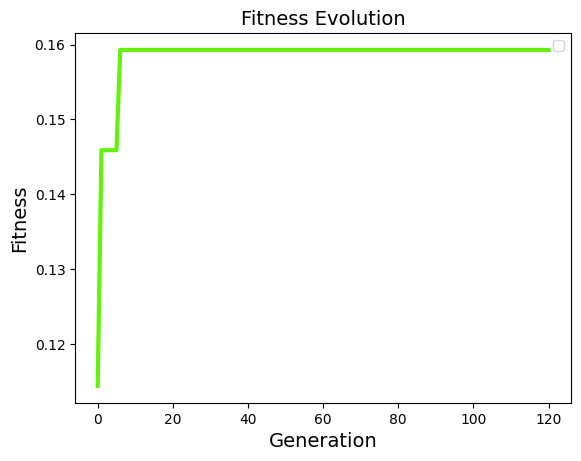

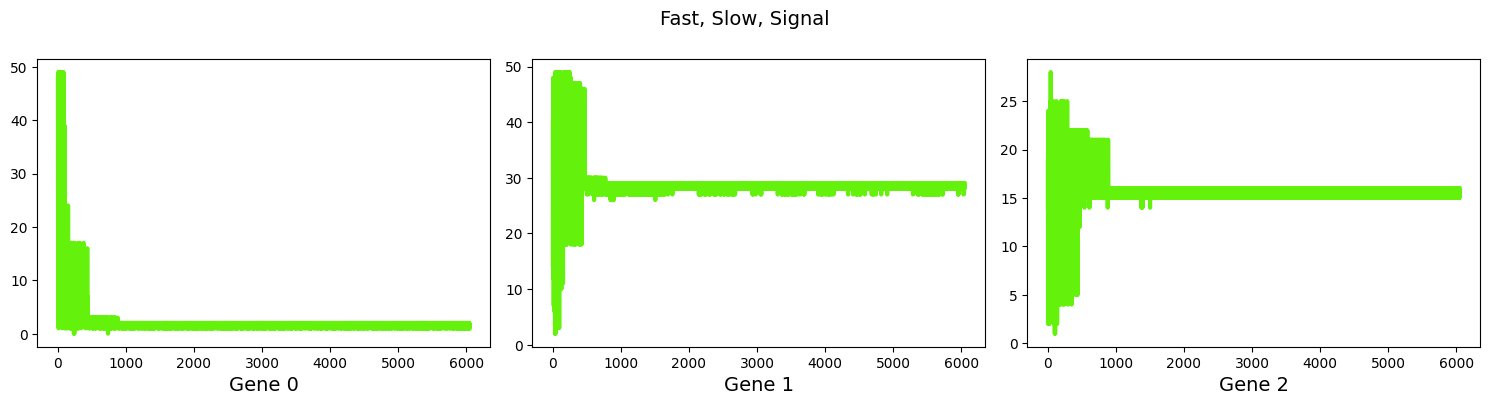

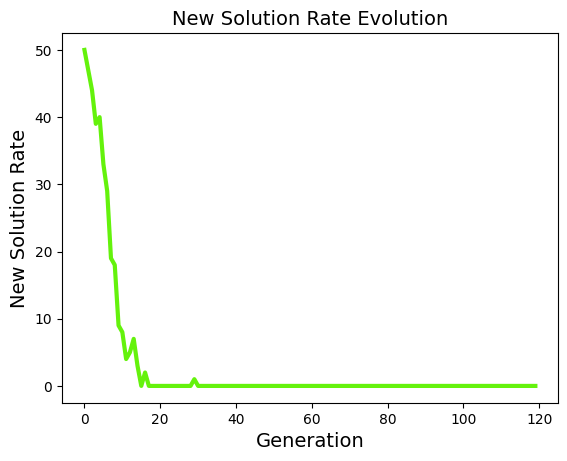

In [89]:
# Assuming you have a DataFrame `df_train` with 'close' prices
optimizer = MACD_GA(df_train=df_train)

# Run the genetic algorithm
optimizer.run_ga()

# Get the best parameters
best_params = optimizer.get_best_parameters()
print("Best Parameters:", best_params)

# Plot the results
optimizer.plot_results()